# Fetal Health Classification Using Machine Learning

## Real-World Data Science Project — Healthcare Domain

This project focuses on analyzing fetal cardiotocography-related measurements and developing machine learning models to classify fetal health status.

The project follows an end-to-end data science workflow including data understanding, data cleaning, exploratory data analysis, visualization, preprocessing, model development, evaluation, and interpretation.

## 1. Problem Statement

Monitoring fetal health is an important part of prenatal care. Cardiotocography records physiological measurements associated with fetal heart rate and uterine activity.

The objective of this project is to analyze the available fetal health measurements, identify important patterns and relationships in the data, and develop machine learning models capable of classifying fetal health status based on the provided features.

This is a multiclass classification problem in which the target variable is `fetal_health`.

## 2. Project Objectives

The main objectives of this project are:

1. Understand the structure and characteristics of the fetal health dataset.
2. Identify and handle data quality issues such as missing values and duplicate records.
3. Perform exploratory data analysis to understand feature distributions and relationships.
4. Visualize important patterns within the dataset.
5. Examine the distribution of the fetal health target classes.
6. Prepare and preprocess the data for machine learning.
7. Train multiple classification algorithms.
8. Compare model performance using suitable evaluation metrics.
9. Identify the most important features influencing fetal health classification.
10. Draw meaningful conclusions from the analysis and model results.

## 3. Import Required Libraries

The required Python libraries are imported for data manipulation, numerical operations, visualization, preprocessing, machine learning, and model evaluation.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

## 4. Load the Dataset

The fetal health dataset is loaded into a Pandas DataFrame for further analysis.

In [ ]:
df = pd.read_csv("fetal_health.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### 4.1 Preview the Dataset

The first five records are displayed to understand the structure of the dataset and the type of values stored in each feature.

In [ ]:
df.head(10)

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
0,120.0,0.000,0.0,0.000,0.000,0.0,0.000,73.0,0.5,43.0,...,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0,2.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.000,17.0,2.1,0.0,...,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0,1.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.1,0.0,...,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0,1.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.000,16.0,2.4,0.0,...,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0,1.0
5,134.0,0.001,0.0,0.010,0.009,0.0,0.002,26.0,5.9,0.0,...,50.0,200.0,5.0,3.0,76.0,107.0,107.0,170.0,0.0,3.0
6,134.0,0.001,0.0,0.013,0.008,0.0,0.003,29.0,6.3,0.0,...,50.0,200.0,6.0,3.0,71.0,107.0,106.0,215.0,0.0,3.0
7,122.0,0.000,0.0,0.000,0.000,0.0,0.000,83.0,0.5,6.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
8,122.0,0.000,0.0,0.002,0.000,0.0,0.000,84.0,0.5,5.0,...,62.0,130.0,0.0,0.0,122.0,122.0,123.0,3.0,1.0,3.0
9,122.0,0.000,0.0,0.003,0.000,0.0,0.000,86.0,0.3,6.0,...,62.0,130.0,1.0,0.0,122.0,122.0,123.0,1.0,1.0,3.0


### 4.2 Dataset Dimensions

The number of rows and columns in the dataset is checked to understand its overall size.

In [ ]:
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])
print("Dataset Shape:",df.shape)

Number of rows: 2126
Number of columns: 22
Dataset Shape: (2126, 22)


### 4.3 Feature Names

The column names are examined to identify the predictor variables and the target variable available in the dataset.


In [ ]:
df.columns

Index(['baseline value', 'accelerations', 'fetal_movement',
       'uterine_contractions', 'light_decelerations', 'severe_decelerations',
       'prolongued_decelerations', 'abnormal_short_term_variability',
       'mean_value_of_short_term_variability',
       'percentage_of_time_with_abnormal_long_term_variability',
       'mean_value_of_long_term_variability', 'histogram_width',
       'histogram_min', 'histogram_max', 'histogram_number_of_peaks',
       'histogram_number_of_zeroes', 'histogram_mode', 'histogram_mean',
       'histogram_median', 'histogram_variance', 'histogram_tendency',
       'fetal_health'],
      dtype='object')

### 4.4 Dataset Information

The dataset structure is inspected to understand the number of non-null values, feature data types, and memory usage.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 22 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   baseline value                                          2126 non-null   float64
 1   accelerations                                           2126 non-null   float64
 2   fetal_movement                                          2126 non-null   float64
 3   uterine_contractions                                    2126 non-null   float64
 4   light_decelerations                                     2126 non-null   float64
 5   severe_decelerations                                    2126 non-null   float64
 6   prolongued_decelerations                                2126 non-null   float64
 7   abnormal_short_term_variability                         2126 non-null   float64
 8   mean_value_of_short_term_variability  

### 4.5 Statistical Summary

Descriptive statistics are generated for the numerical features to understand their central tendency, spread, and value ranges.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
baseline value,2126.0,133.303857,9.840844,106.0,126.000,133.000,140.000,160.000
accelerations,2126.0,0.003178,0.003866,0.0,0.000,0.002,0.006,0.019
fetal_movement,2126.0,0.009481,0.046666,0.0,0.000,0.000,0.003,0.481
uterine_contractions,2126.0,0.004366,0.002946,0.0,0.002,0.004,0.007,0.015
light_decelerations,2126.0,0.001889,0.002960,0.0,0.000,0.000,0.003,0.015
severe_decelerations,2126.0,0.000003,0.000057,0.0,0.000,0.000,0.000,0.001
prolongued_decelerations,2126.0,0.000159,0.000590,0.0,0.000,0.000,0.000,0.005
abnormal_short_term_variability,2126.0,46.990122,17.192814,12.0,32.000,49.000,61.000,87.000
mean_value_of_short_term_variability,2126.0,1.332785,0.883241,0.2,0.700,1.200,1.700,7.000
percentage_of_time_with_abnormal_long_term_variability,2126.0,9.846660,18.396880,0.0,0.000,0.000,11.000,91.000


## 5. Data Quality Assessment and Cleaning

Before performing exploratory data analysis and machine learning, the dataset is examined for potential data quality issues.

This section checks for missing values, duplicate records, unique values, target class distribution, and potentially suspicious values. Appropriate cleaning decisions are then made based on the findings.

### 5.1 Checking Missing Values

Missing values can affect statistical analysis and machine learning models. Therefore, each column is examined for null values before further analysis.

In [ ]:
missing_values = df.isnull().sum()
print("Missing Values in each columns:")
print(missing_values)
print("\nTotal Missing Values:",missing_values.sum())

Missing Values in each columns:
baseline value                                            0
accelerations                                             0
fetal_movement                                            0
uterine_contractions                                      0
light_decelerations                                       0
severe_decelerations                                      0
prolongued_decelerations                                  0
abnormal_short_term_variability                           0
mean_value_of_short_term_variability                      0
percentage_of_time_with_abnormal_long_term_variability    0
mean_value_of_long_term_variability                       0
histogram_width                                           0
histogram_min                                             0
histogram_max                                             0
histogram_number_of_peaks                                 0
histogram_number_of_zeroes                                0
histogra

### 5.2 Checking Duplicate Records

Duplicate observations may unnecessarily repeat the same information and can influence analysis or model training. The dataset is therefore checked for completely duplicated rows.

In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of Duplicate rows:",duplicate_count)

Number of Duplicate rows: 13


### 5.3 Inspecting Duplicate Records

The duplicated observations are displayed before removal to verify that they represent complete duplicate rows.

In [ ]:
duplicate_rows = df[df.duplicated(keep=False)]
duplicate_rows

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency,fetal_health
67,140.0,0.007,0.000,0.004,0.0,0.0,0.0,34.0,1.2,0.0,...,119.0,179.0,2.0,0.0,156.0,153.0,155.0,5.0,0.0,1.0
68,140.0,0.007,0.000,0.004,0.0,0.0,0.0,34.0,1.2,0.0,...,119.0,179.0,2.0,0.0,156.0,153.0,155.0,5.0,0.0,1.0
229,123.0,0.003,0.003,0.000,0.0,0.0,0.0,52.0,0.8,2.0,...,50.0,140.0,7.0,0.0,129.0,128.0,130.0,4.0,1.0,1.0
233,123.0,0.000,0.000,0.000,0.0,0.0,0.0,49.0,0.8,7.0,...,63.0,137.0,2.0,0.0,129.0,127.0,129.0,2.0,1.0,1.0
234,123.0,0.000,0.000,0.000,0.0,0.0,0.0,49.0,0.8,7.0,...,63.0,137.0,2.0,0.0,129.0,127.0,129.0,2.0,1.0,1.0
304,145.0,0.000,0.020,0.000,0.0,0.0,0.0,77.0,0.2,45.0,...,129.0,150.0,1.0,0.0,146.0,145.0,147.0,0.0,1.0,2.0
306,145.0,0.000,0.020,0.000,0.0,0.0,0.0,77.0,0.2,45.0,...,129.0,150.0,1.0,0.0,146.0,145.0,147.0,0.0,1.0,2.0
323,135.0,0.000,0.000,0.000,0.0,0.0,0.0,62.0,0.5,71.0,...,71.0,168.0,3.0,0.0,143.0,142.0,144.0,1.0,1.0,3.0
324,135.0,0.000,0.000,0.000,0.0,0.0,0.0,62.0,0.5,71.0,...,71.0,168.0,3.0,0.0,143.0,142.0,144.0,1.0,1.0,3.0
326,144.0,0.000,0.019,0.000,0.0,0.0,0.0,76.0,0.4,61.0,...,71.0,152.0,3.0,0.0,145.0,144.0,146.0,2.0,1.0,2.0


### 5.4 Removing Duplicate Records

The dataset contains completely duplicated rows. These duplicate observations are removed to avoid repeated records influencing the analysis and machine learning models.

In [ ]:
df = df.drop_duplicates().reset_index(drop=True)
print("Dataset shape after removing Duplicates:")
df.shape

Dataset shape after removing Duplicates:


(2113, 22)

### 5.5 Verifying Duplicate Removal

After removing the duplicate observations, the dataset is checked again to confirm that no complete duplicate rows remain.

In [ ]:
print("Duplicate rows after cleaning:",
      df.duplicated().sum())

Duplicate rows after cleaning: 0


In [ ]:
df.to_csv("fetal_health_cleaned.csv")

### 5.6 Checking Unique Values

The number of unique values in each feature is examined to better understand the structure of the variables and identify features with limited or unusual variation.

In [ ]:
unique_counts = df.nunique().sort_values()
unique_counts

,0
severe_decelerations,2
fetal_health,3
histogram_tendency,3
prolongued_decelerations,6
histogram_number_of_zeroes,9
uterine_contractions,16
light_decelerations,16
histogram_number_of_peaks,18
accelerations,20
baseline value,48


### 5.7 Examining the Target Variable

The unique values of the target variable `fetal_health` are examined to determine the number of classes present in the classification problem.

In [ ]:
print("Unique target values:")
print(sorted(df['fetal_health'].unique()))

print("\nNumber of target classes:")
print(df['fetal_health'].nunique())

Unique target values:
[np.float64(1.0), np.float64(2.0), np.float64(3.0)]

Number of target classes:
3


### 5.8 Target Class Distribution

The frequency and percentage distribution of the target classes are examined to determine whether the dataset is balanced or imbalanced.

In [ ]:
class_counts = df['fetal_health'].value_counts().sort_index()
calss_percentage = df['fetal_health'].value_counts(normalize=True).sort_index() * 100
class_ditribution = pd.DataFrame({
    "count":class_counts,
    "percentage":calss_percentage.round(2)
})
class_ditribution

,count,percentage
fetal_health,,
1.0,1646,77.90
2.0,292,13.82
3.0,175,8.28


### 5.9 Visualizing the Target Class Distribution

A count plot is used to visually compare the number of observations belonging to each fetal health class.

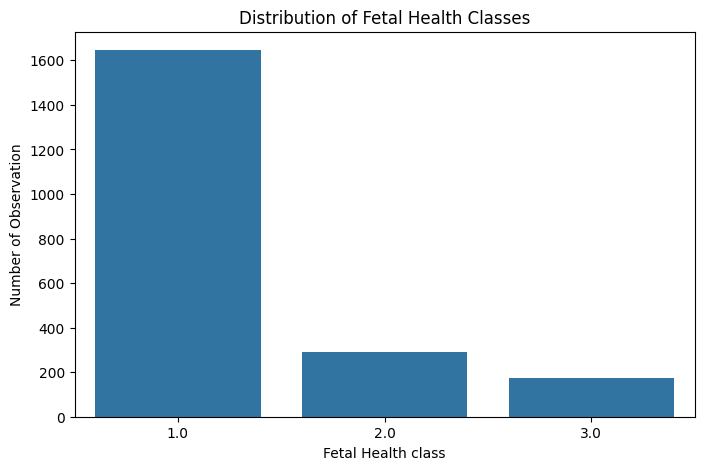

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df,
    x="fetal_health"
)
plt.title("Distribution of Fetal Health Classes")
plt.xlabel("Fetal Health class")
plt.ylabel("Number of Observation")
plt.show()

### 5.10 Checking Infinite Values

The numerical dataset is checked for positive or negative infinite values, which could cause problems during statistical analysis or machine learning.

In [ ]:
infinite_values = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

print("Number of infinite values:", infinite_values)

Number of infinite values: 0


### 5.11 Data Quality Summary

The initial data quality assessment produced the following findings:

- The dataset contained no missing values.
- Completely duplicated observations were identified and removed.
- The cleaned dataset contains 2,113 observations and 22 variables.
- No infinite numerical values were detected.
- The target variable contains three distinct classes, confirming a multiclass classification problem.
- The target classes are imbalanced, which will be considered during model development and evaluation.

The dataset is now ready for exploratory data analysis.

## 6. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distributions, patterns, relationships, and variability present in the dataset.

The analysis focuses on:

- Distribution of numerical features
- Detection and examination of potential outliers
- Correlations between variables
- Relationships between selected features and fetal health classes
- Identification of potentially informative features for classification

### 6.1 Distribution of Numerical Features

Histograms are used to examine the distribution, spread, skewness, and concentration of values across the numerical features.

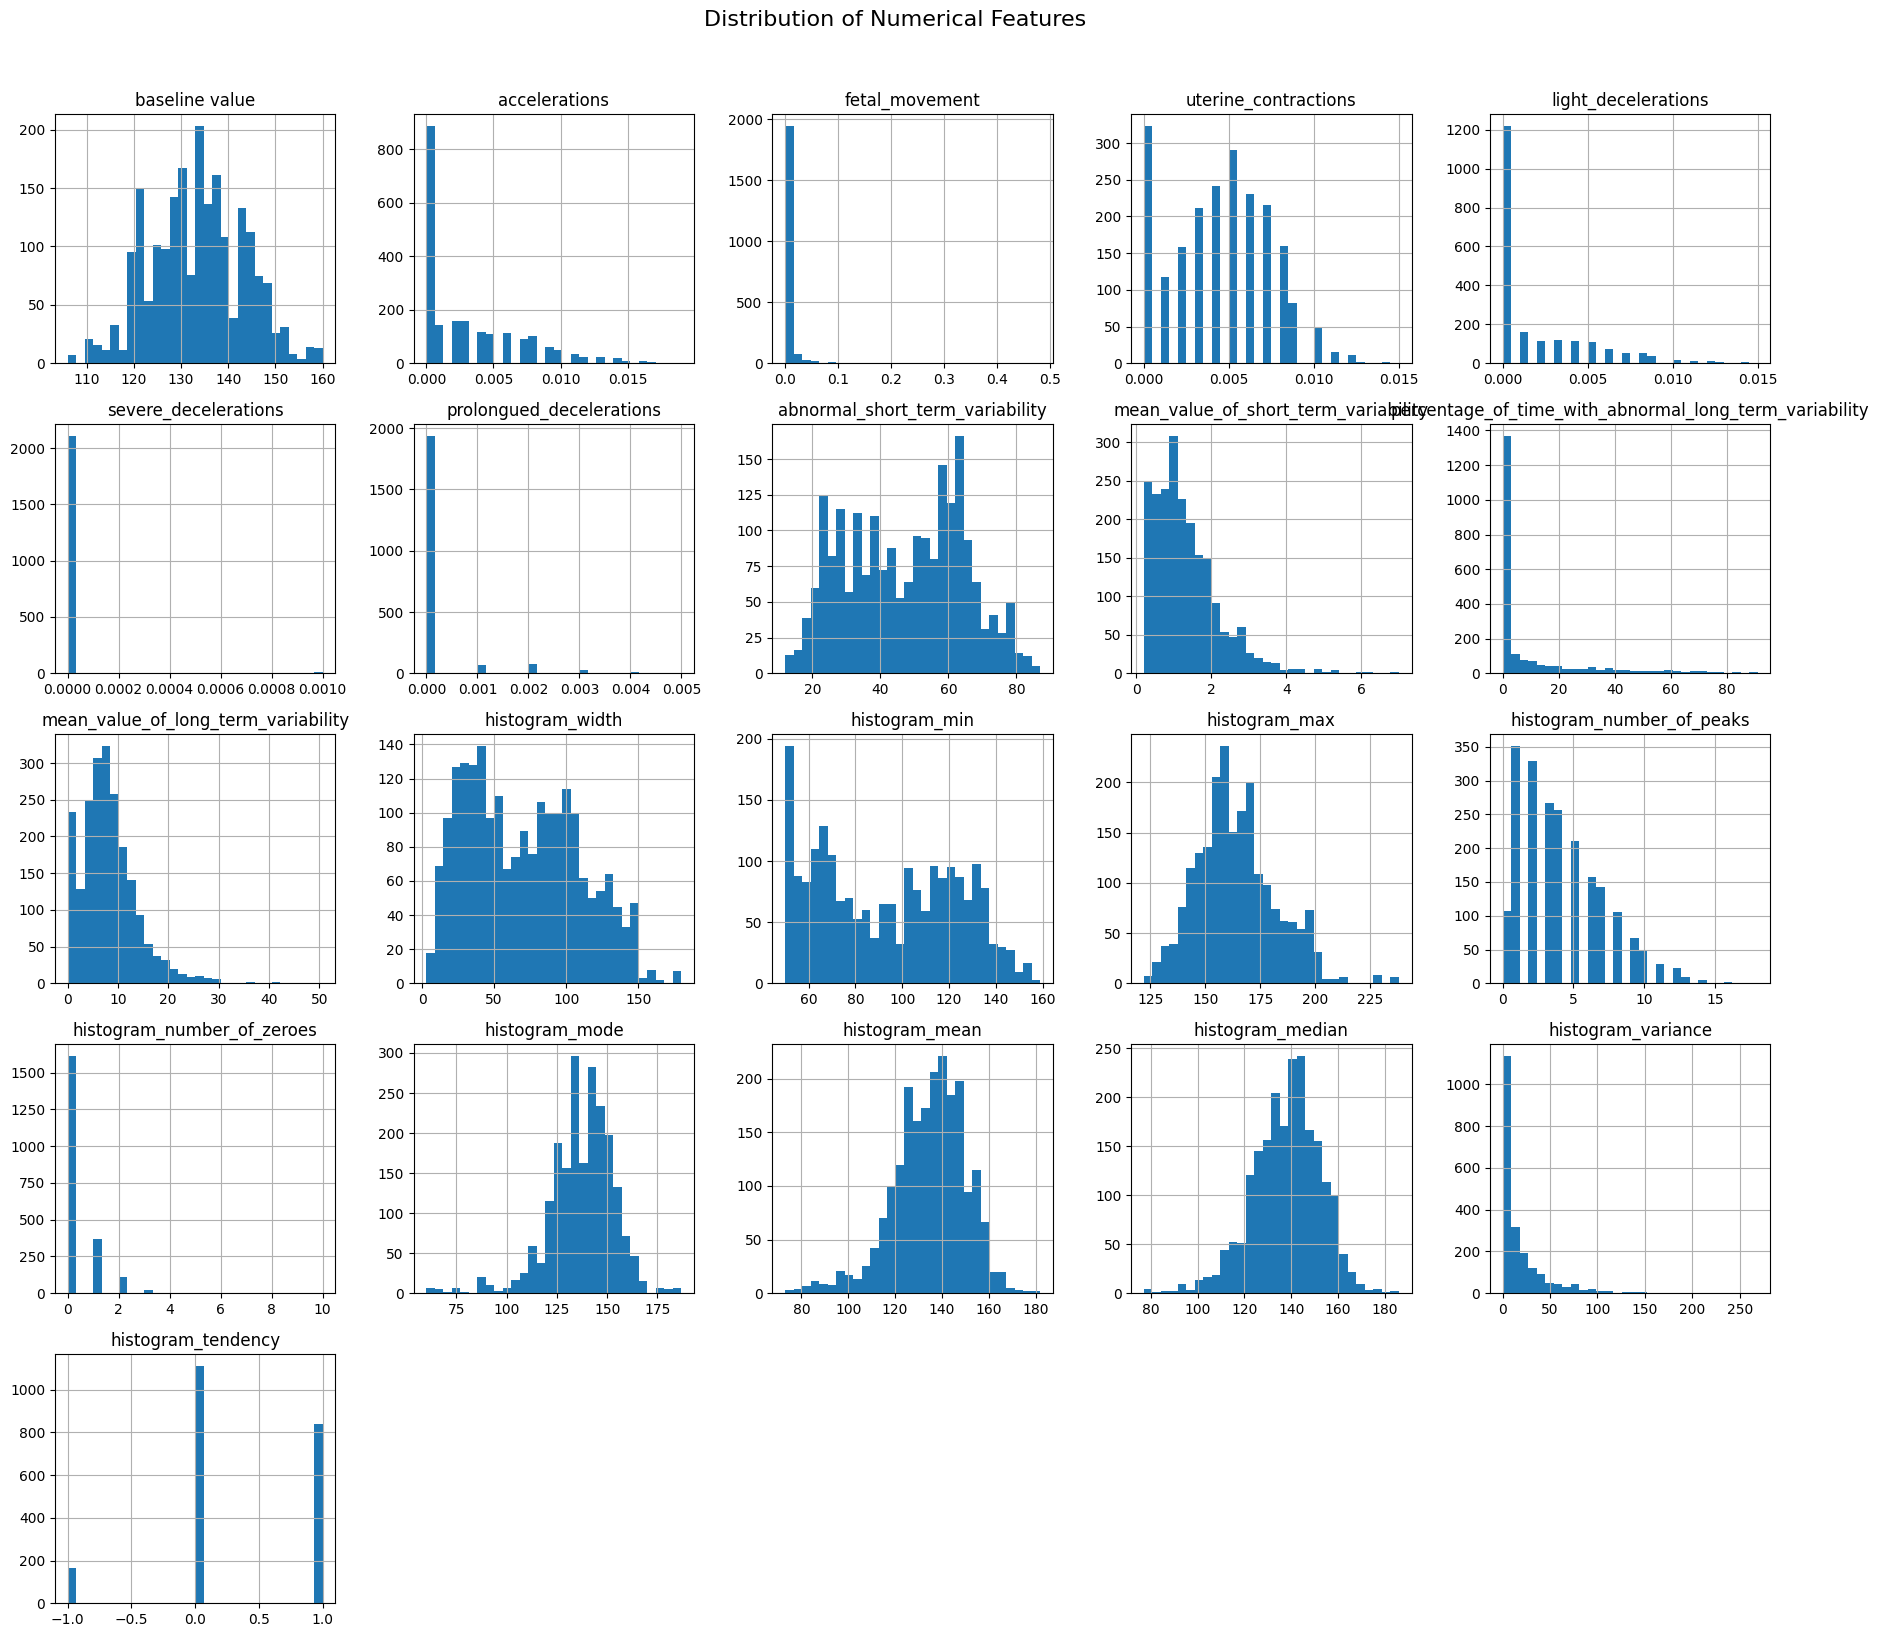

In [ ]:
features = df.drop(columns=["fetal_health"])
features.hist(
    figsize=(18,16),
    bins=30
)
plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16,
    y=1.02
)
plt.tight_layout()
plt.show()

**Observation:**  
The predictor variables exhibit different distribution patterns. Some features appear relatively concentrated, while others show skewness, wide ranges, or substantial concentrations around particular values.

These differences suggest that the features have varying scales and statistical characteristics, which will be considered during preprocessing and model development.

### 6.2 Examining Potential Outliers

Boxplots are used to examine the spread of each predictor and identify observations that fall far from the central range of the data.

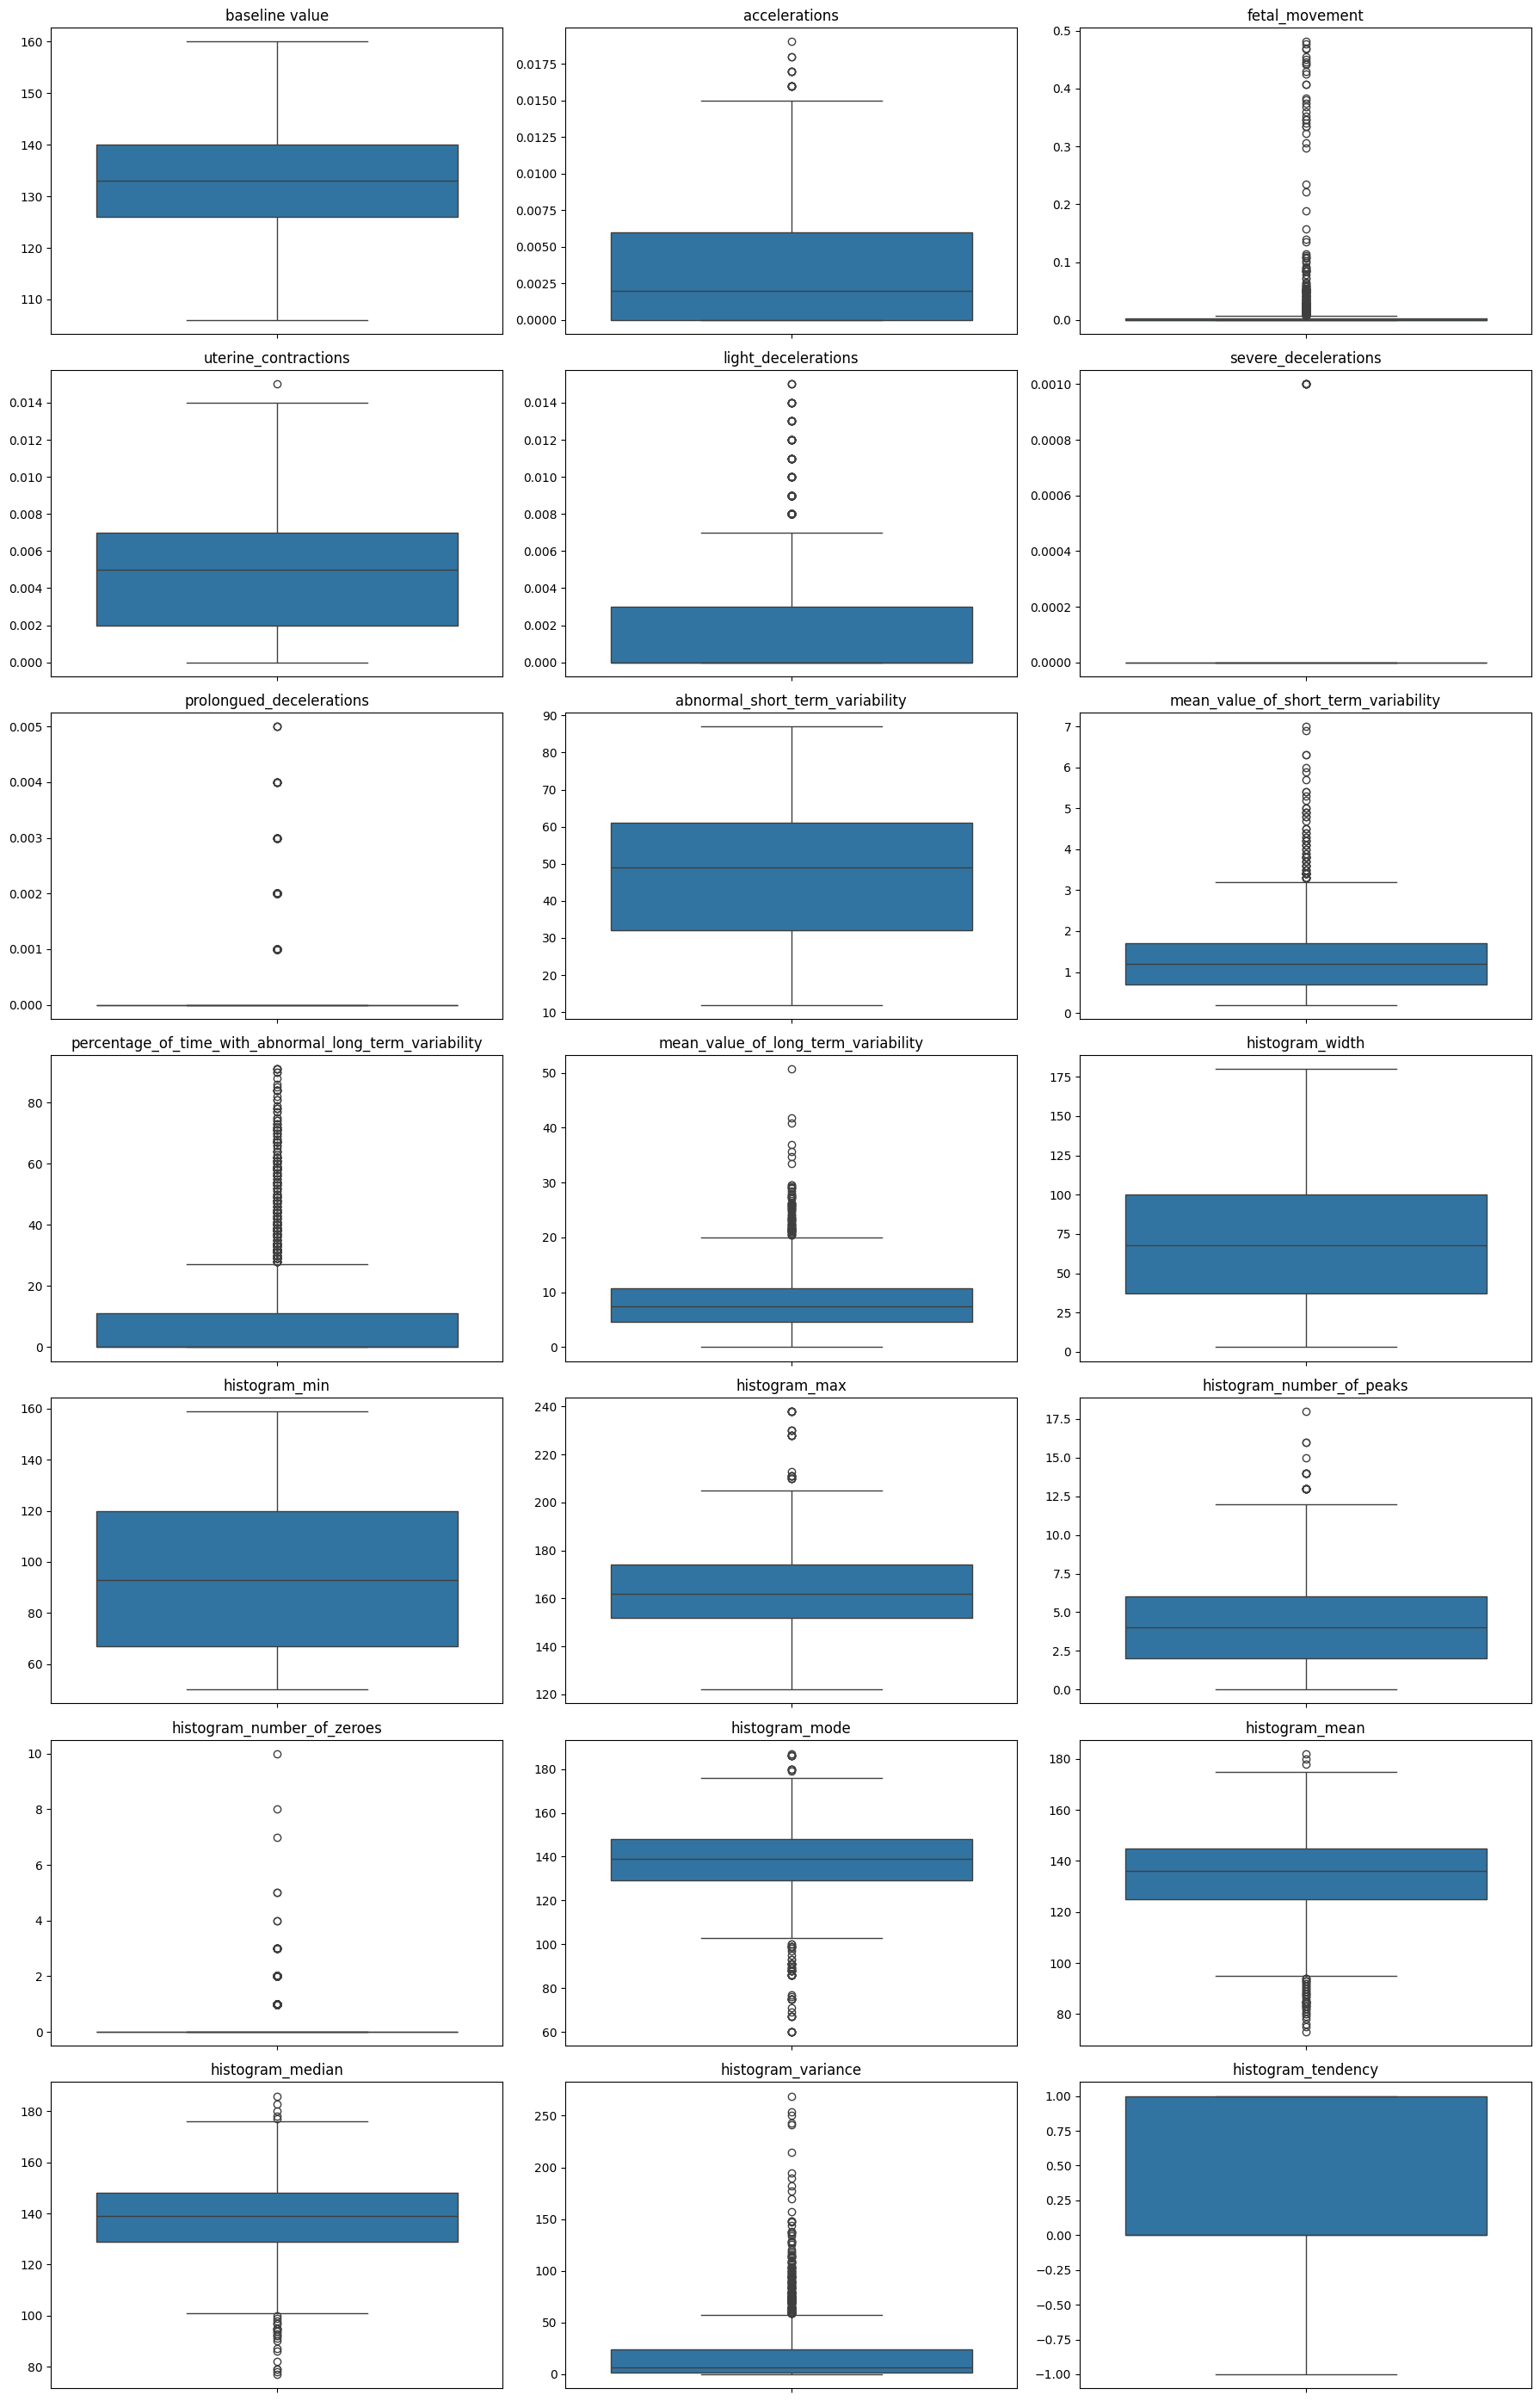

In [ ]:
featur_columns = df.drop(columns=["fetal_health"]).columns

fig,axes = plt.subplots(7,3,figsize=(18,28))
axes = axes.flatten()

for i,column in enumerate(featur_columns):
  sns.boxplot(
      y=df[column],
      ax=axes[i]
  )
  axes[i].set_title(column)
  axes[i].set_ylabel("")
plt.tight_layout()
plt.show()

**Observation:**  
Several features contain observations outside their typical ranges according to the boxplots. However, these observations are not automatically removed.

Because the dataset contains physiological measurements, extreme values may represent meaningful cases rather than data-entry errors. Their potential influence will therefore be considered carefully rather than treating every statistical outlier as invalid data.

### 6.3 Correlation Analysis

A correlation matrix is used to examine linear relationships between numerical variables. This helps identify strongly related features and provides an initial view of which variables may be associated with the target.

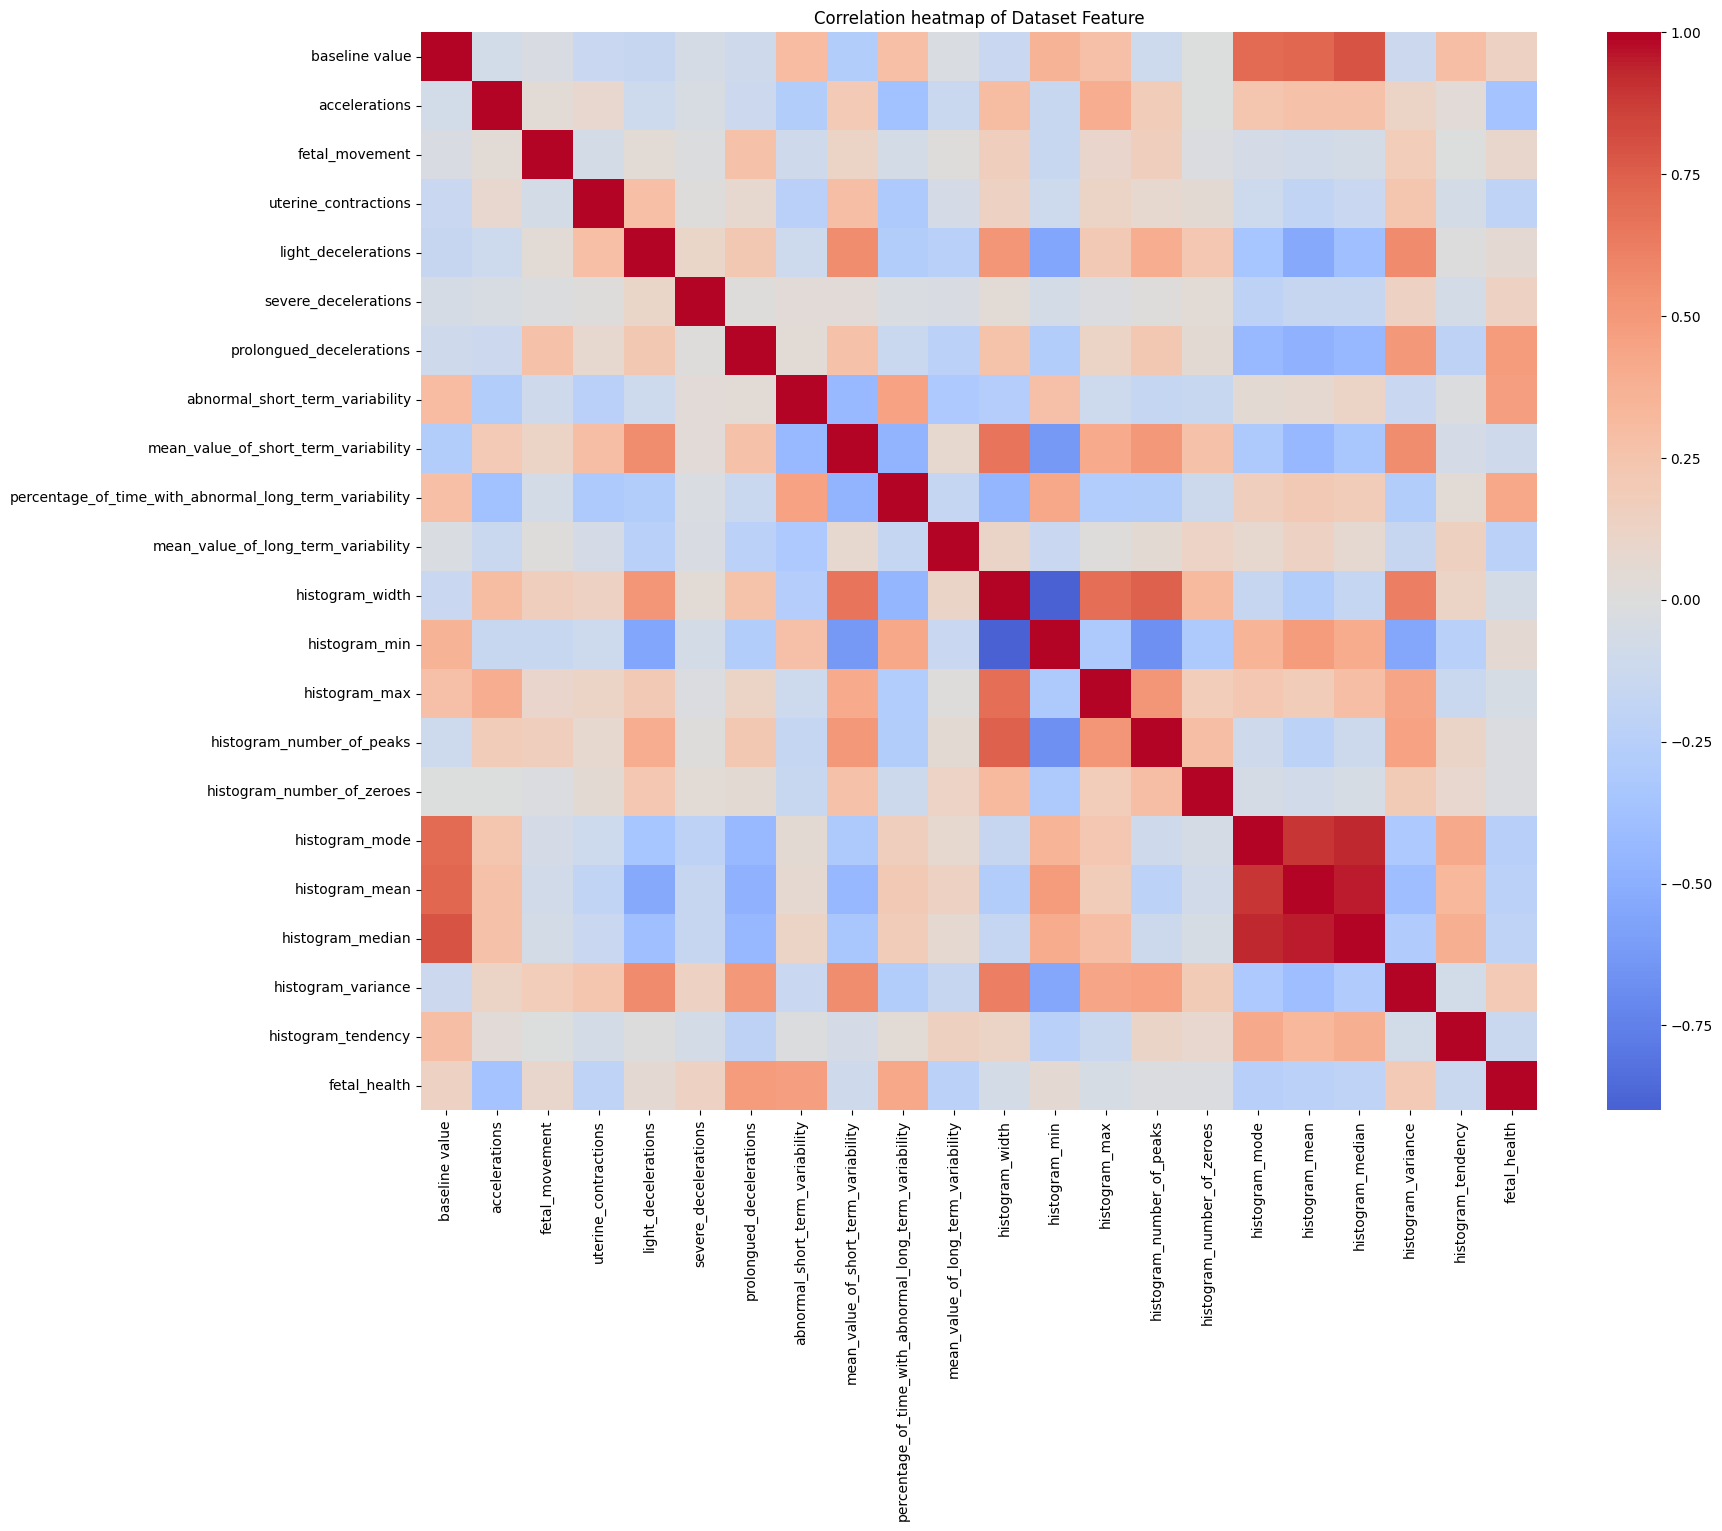

In [ ]:
correlation_matrix = df.corr()

plt.figure(figsize=(18,14))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)
plt.title("Correlation heatmap of Dataset Feature")
plt.show()

### 6.4 Correlation with the Target Variable

The correlations between the predictor variables and `fetal_health` are examined to identify features showing stronger linear associations with the encoded target values.

In [ ]:
target_correlation  = (
    df.corr()["fetal_health"]
    .drop("fetal_health")
    .sort_values()
)
target_correlation

,fetal_health
accelerations,-0.363947
histogram_mode,-0.253612
histogram_mean,-0.230243
mean_value_of_long_term_variability,-0.225685
histogram_median,-0.208334
uterine_contractions,-0.205117
histogram_tendency,-0.135573
mean_value_of_short_term_variability,-0.101089
histogram_width,-0.069529
histogram_max,-0.046480


The target correlations are visualized to make the relative strength and direction of the linear associations easier to compare.

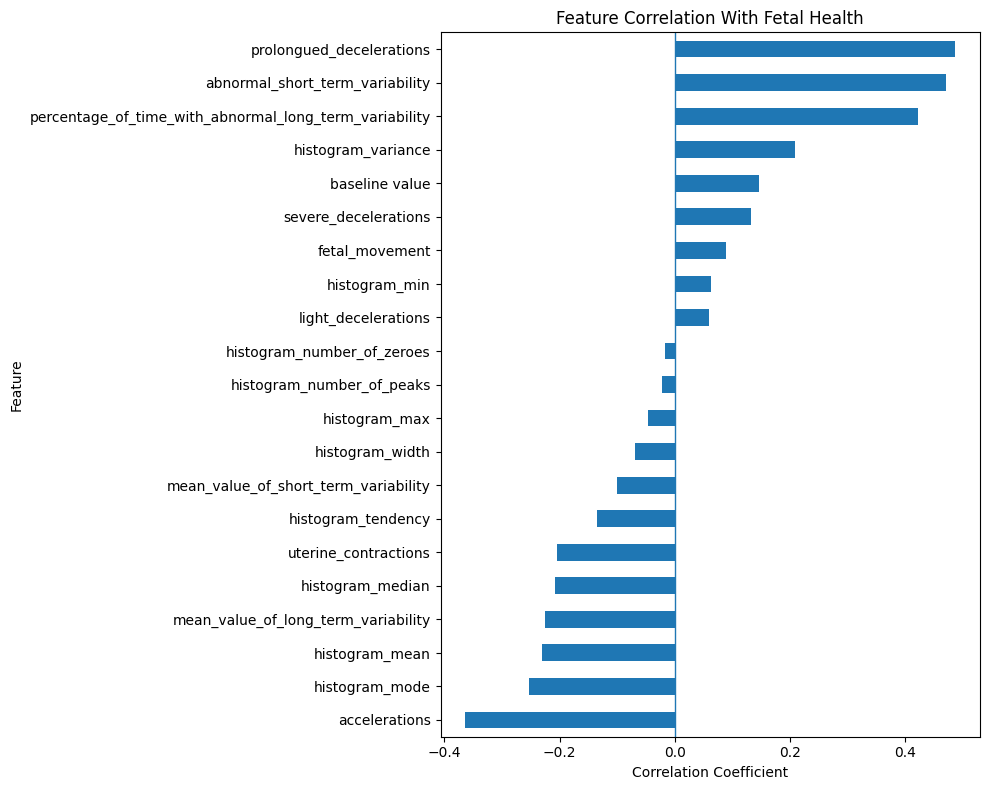

In [ ]:
plt.figure(figsize=(10,8))

target_correlation.plot(kind="barh")

plt.title("Feature Correlation With Fetal Health")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Feature")

plt.axvline(0,linewidth=1)
plt.tight_layout()
plt.show()

### 6.5 Identifying Features with Stronger Target Associations

The features with the largest absolute correlations with the encoded target are identified for closer exploratory comparison across fetal health classes.

In [ ]:
top_features = (
    target_correlation
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index
    .tolist()
)
print("Top features based on absloute target correlation")
for feature in top_features:
  print(feature)

Top features based on absloute target correlation
prolongued_decelerations
abnormal_short_term_variability
percentage_of_time_with_abnormal_long_term_variability
accelerations
histogram_mode
histogram_mean


### 6.6 Comparing Important Features Across Fetal Health Classes

Boxplots are used to compare the distributions of features with stronger target associations across the three fetal health classes.

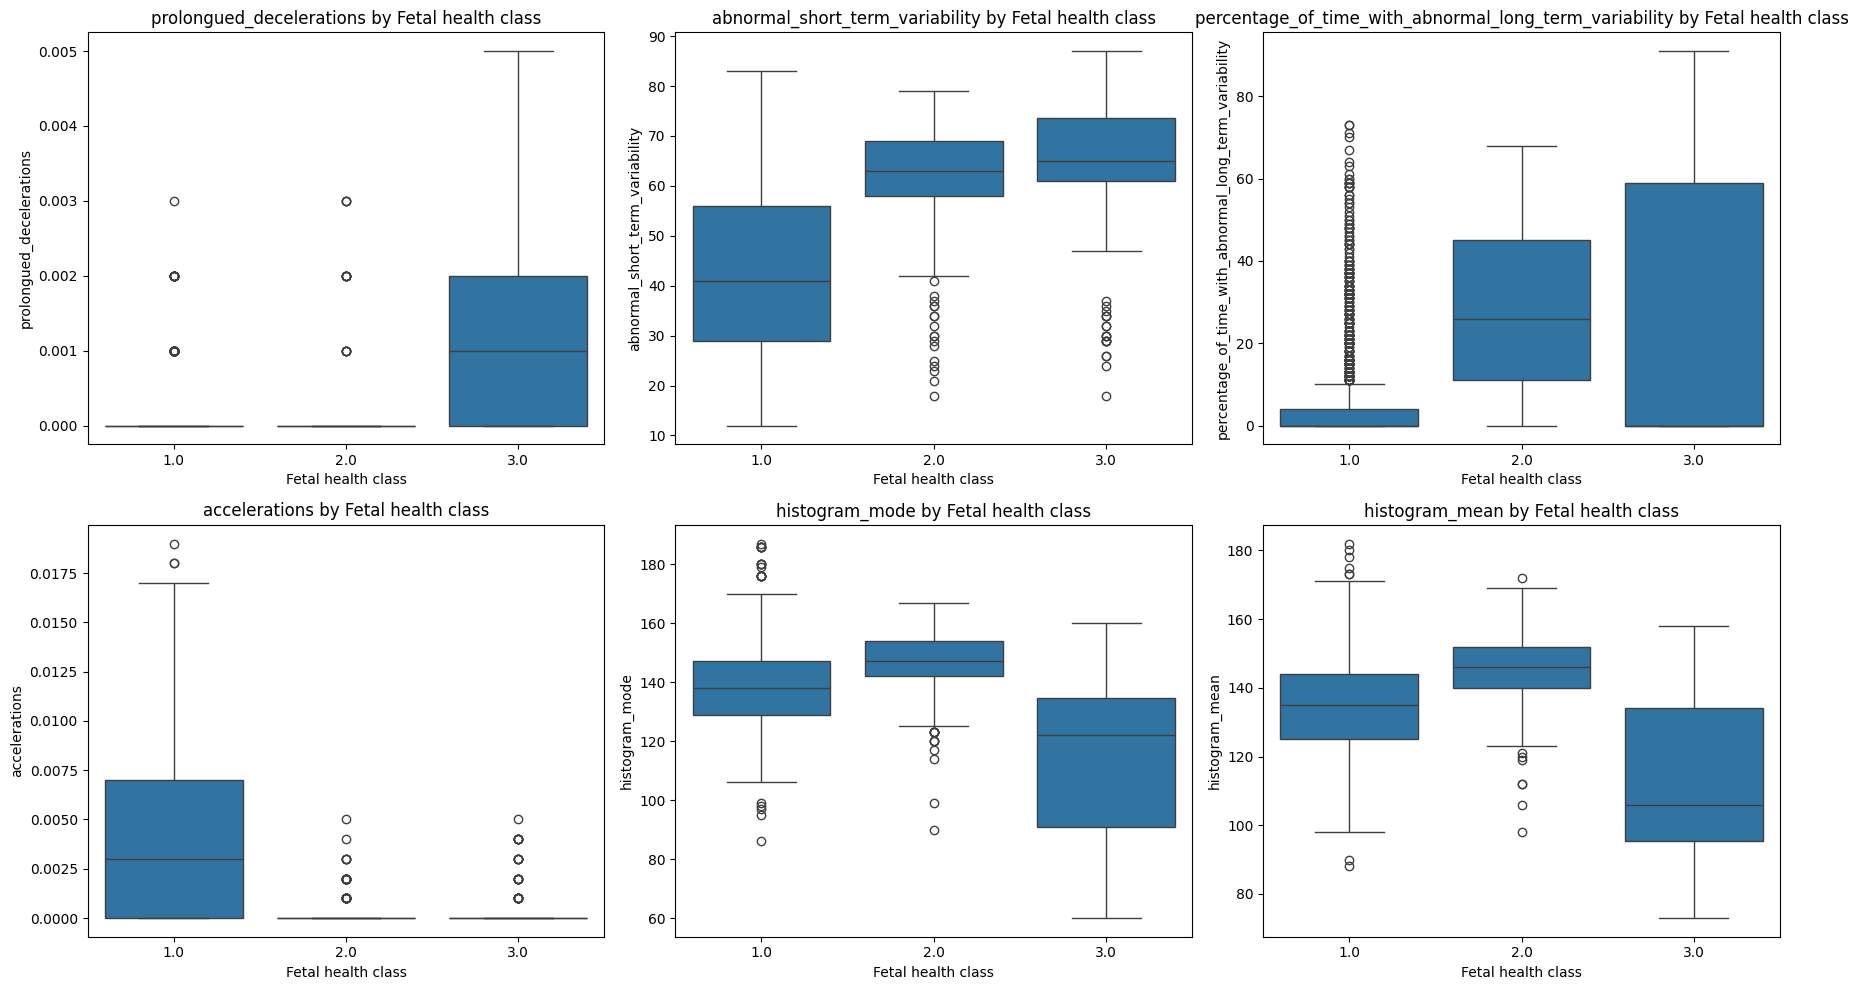

In [ ]:
fig,axes = plt.subplots(2,3,figsize=(18,10))
axes = axes.flatten()

for i,feature in enumerate(top_features):
  sns.boxplot(
      data=df,
      x="fetal_health",
      y=feature,
      ax=axes[i]
  )
  axes[i].set_title(f"{feature} by Fetal health class")
  axes[i].set_xlabel("Fetal health class")
  axes[i].set_ylabel(feature)
plt.tight_layout()
plt.show()

### 6.7 Class-wise Summary of Important Features

The mean values of the selected features are compared across fetal health classes to complement the visual analysis.

In [ ]:
class_feature_means = (
    df.groupby("fetal_health")[top_features]
    .mean()
    .round(3)
)
class_feature_means

,prolongued_decelerations,abnormal_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,accelerations,histogram_mode,histogram_mean
fetal_health,,,,,,
1.0,0.000,42.502,5.060,0.004,138.287,135.116
2.0,0.000,61.791,28.832,0.000,146.551,144.747
3.0,0.001,64.554,22.571,0.000,114.446,112.811


### 6.8 Correlation Between Predictor Variables

Strong correlations between predictor variables are examined because highly related features may contain overlapping information.

In [ ]:
feature_corr = features.corr().abs()
upper_triangle = feature_corr.where(
    np.triu(
        np.ones(feature_corr.shape),
        k=1
    ).astype(bool)
)
high_corr_pairs = (
    upper_triangle.stack()
    .sort_values(ascending=False)
)
high_corr_pairs.head(10)

histogram_mean   histogram_median             0.948077
histogram_mode   histogram_median             0.933166
histogram_width  histogram_min                0.899054
histogram_mode   histogram_mean               0.893083
baseline value   histogram_median             0.788487
histogram_width  histogram_number_of_peaks    0.746894
baseline value   histogram_mean               0.722152
                 histogram_mode               0.708074
histogram_width  histogram_max                0.692645
histogram_min    histogram_number_of_peaks    0.670410
dtype: float64

## 6.9 Exploratory Data Analysis Summary

The exploratory analysis revealed several important characteristics of the dataset:

- Predictor variables show different distribution patterns and measurement scales.
- Several features contain statistical outliers; however, these were retained because unusual physiological measurements may represent meaningful observations.
- Correlation analysis revealed varying levels of association among the predictor variables.
- Some features show stronger linear associations with the encoded fetal health target than others.
- Class-wise comparisons indicate that selected measurements vary across fetal health categories, suggesting useful predictive information.
- Some predictor variables are strongly correlated with one another and may contain overlapping information.
- The previously identified target-class imbalance remains an important consideration for model evaluation.

These findings provide guidance for the preprocessing and machine learning stages.

## 7. Data Preprocessing

Before training machine learning models, the dataset is prepared by separating the predictor variables from the target variable and dividing the data into training and testing sets.

Because the target classes are imbalanced, stratified sampling is used during the train-test split to preserve approximately the same class proportions in both subsets.

Feature scaling will also be applied for algorithms that are sensitive to differences in feature magnitude.

### 7.1 Separating Features and Target

The predictor variables are stored in `X`, while the target variable `fetal_health` is stored in `y`.

In [ ]:
x = df.drop(columns=["fetal_health"])
y = df["fetal_health"]
print("Feature matrix shape:",x.shape)
print("Target vector Shape:",y.shape)

Feature matrix shape: (2113, 21)
Target vector Shape: (2113,)


The separation of predictor and target variables is verified before splitting the dataset.

In [ ]:
print("First five feature columns:")
display(x.head())
print("\nFirst five target values:")
display(y.head())

First five feature columns:


,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
0,120.0,0.000,0.0,0.000,0.000,0.0,0.0,73.0,0.5,43.0,...,64.0,62.0,126.0,2.0,0.0,120.0,137.0,121.0,73.0,1.0
1,132.0,0.006,0.0,0.006,0.003,0.0,0.0,17.0,2.1,0.0,...,130.0,68.0,198.0,6.0,1.0,141.0,136.0,140.0,12.0,0.0
2,133.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.1,0.0,...,130.0,68.0,198.0,5.0,1.0,141.0,135.0,138.0,13.0,0.0
3,134.0,0.003,0.0,0.008,0.003,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,11.0,0.0,137.0,134.0,137.0,13.0,1.0
4,132.0,0.007,0.0,0.008,0.000,0.0,0.0,16.0,2.4,0.0,...,117.0,53.0,170.0,9.0,0.0,137.0,136.0,138.0,11.0,1.0



First five target values:


,fetal_health
0,2.0
1,1.0
2,1.0
3,1.0
4,1.0


### 7.2 Splitting the Dataset

The dataset is divided into training and testing subsets. The training data will be used to learn model parameters, while the testing data will be reserved for evaluating performance on unseen observations.

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### 7.3 Verifying the Train-Test Split

The dimensions of the training and testing subsets are checked after splitting.

In [ ]:
print("x train shape:",x_train.shape)
print("x test shape:",x_test.shape)
print("y train shape:",y_train.shape)
print("y_test shape:",y_test.shape)


x train shape: (1690, 21)
x test shape: (423, 21)
y train shape: (1690,)
y_test shape: (423,)


### 7.4 Verifying Class Distribution After Splitting

The class percentages in the complete dataset, training set, and testing set are compared to confirm that stratified sampling preserved the target distribution.

In [ ]:
distribution_check = pd.DataFrame({
    "Full Dataset (%)": y.value_counts(normalize=True).sort_index() * 100,
    "Training Set (%)": y_train.value_counts(normalize=True).sort_index() * 100,
    "Testing Set (%)": y_test.value_counts(normalize=True).sort_index() * 100
}).round(2)

distribution_check

,Full Dataset (%),Training Set (%),Testing Set (%)
fetal_health,,,
1.0,77.90,77.87,78.01
2.0,13.82,13.85,13.71
3.0,8.28,8.28,8.27


### 7.5 Feature Scaling

The predictor variables have different numerical ranges. Standardization is therefore prepared for models that are sensitive to feature magnitude.

The scaler is fitted only on the training data and then applied to both the training and testing sets. This prevents information from the test set from influencing the preprocessing stage.

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

The standardized arrays are converted back into Pandas DataFrames while preserving the original feature names and indices.

In [ ]:
x_train_scaled = pd.DataFrame(
    x_train_scaled,
    columns=x_train.columns,
    index=x_train.index
)

x_test_scaled = pd.DataFrame(
    x_test_scaled,
    columns=x_test.columns,
    index=x_test.index
)

x_train_scaled.head()

,baseline value,accelerations,fetal_movement,uterine_contractions,light_decelerations,severe_decelerations,prolongued_decelerations,abnormal_short_term_variability,mean_value_of_short_term_variability,percentage_of_time_with_abnormal_long_term_variability,...,histogram_width,histogram_min,histogram_max,histogram_number_of_peaks,histogram_number_of_zeroes,histogram_mode,histogram_mean,histogram_median,histogram_variance,histogram_tendency
1570,-0.121468,-0.564170,-0.207205,0.219671,1.109664,-0.064492,-0.27459,-0.969271,0.531528,-0.268389,...,0.760655,-1.431572,-0.721921,1.017089,-0.450372,0.105283,-0.288589,-0.061282,0.435340,1.126393
1319,-0.528973,1.240136,-0.000123,-0.465282,1.109664,-0.064492,-0.27459,-0.969271,0.645048,-0.542952,...,1.851762,-1.260979,1.954244,2.739760,-0.450372,-0.016461,-0.481209,-0.130052,1.066954,-0.504802
2070,-0.325220,-0.821928,-0.020831,1.247101,-0.639387,-0.064492,-0.27459,1.514401,0.872088,0.115999,...,-1.109815,1.024974,-0.721921,-0.705582,-0.450372,-0.564308,-0.481209,-0.542671,-0.617350,-2.135996
418,0.999171,-0.821928,-0.207205,-0.807758,-0.639387,-0.064492,-0.27459,1.052322,-0.944230,-0.542952,...,-1.213730,1.195568,-0.664981,-0.705582,0.956521,0.348771,0.546100,0.488876,-0.617350,-0.504802
628,1.101047,-0.821928,-0.207205,-1.492712,-0.639387,-0.064492,-0.27459,0.879043,-0.944230,-0.268389,...,-1.525475,1.843823,-0.266404,-1.050116,-0.450372,0.957491,1.252374,1.176574,-0.652440,-0.504802


### 7.6 Verifying Feature Scaling

The means and standard deviations of the standardized training features are examined to verify the scaling process.

In [ ]:
scaling_check = pd.DataFrame({
    "Mean": x_train_scaled.mean(),
    "Std": x_train_scaled.std()
}).round(2)

scaling_check

,Mean,Std
baseline value,0.0,1.0
accelerations,-0.0,1.0
fetal_movement,-0.0,1.0
uterine_contractions,-0.0,1.0
light_decelerations,-0.0,1.0
severe_decelerations,-0.0,1.0
prolongued_decelerations,-0.0,1.0
abnormal_short_term_variability,0.0,1.0
mean_value_of_short_term_variability,0.0,1.0
percentage_of_time_with_abnormal_long_term_variability,-0.0,1.0


## 7.7 Preprocessing Summary

The dataset has now been prepared for machine learning:

- The 21 predictor variables were separated from the `fetal_health` target.
- The cleaned dataset was divided into 80% training data and 20% testing data.
- Stratified sampling was used to preserve the imbalanced target-class distribution across both subsets.
- A fixed random state was used to make the split reproducible.
- StandardScaler was fitted only on the training data to avoid data leakage.
- Standardized versions of the training and testing features were created for scale-sensitive algorithms.
- The original unscaled features are retained for tree-based models that do not require standardization.

The data is now ready for model development.

## 8. Machine Learning Model Development

Machine learning models are developed to classify fetal health status using the available predictor variables.

Because the target variable contains three classes with unequal representation, model performance will be evaluated using multiple metrics rather than accuracy alone.

The evaluation will consider:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

A simple baseline classifier is first established before training more sophisticated classification algorithms.

### 8.1 Importing Model Evaluation Metrics

Several classification metrics are imported to evaluate both overall model performance and performance across individual fetal health classes.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [ ]:
def evaluate_model(model_name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )
    recall = recall_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    print(f"{model_name}")
    print("-" * 50)
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall   : {recall:.4f}")
    print(f"Macro F1-score : {f1:.4f}")

    print("\nClassification Report:\n")
    print(
        classification_report(
            y_true,
            y_pred,
            zero_division=0
        )
    )

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")

    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Macro Precision": precision,
        "Macro Recall": recall,
        "Macro F1": f1
    }

A list is initialized to store the evaluation results of each model for later comparison.

In [ ]:
model_results = []

### 8.3 Baseline Classifier

A baseline classifier is trained using the most frequent target class strategy.

This model does not learn meaningful relationships between the predictor variables and the target. Instead, it provides a minimum benchmark that more sophisticated models should outperform.

In [ ]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(
    strategy="most_frequent"
)

baseline_model.fit(x_train, y_train)

baseline_predictions = baseline_model.predict(x_test)

Baseline Classifier
--------------------------------------------------
Accuracy       : 0.7801
Macro Precision: 0.2600
Macro Recall   : 0.3333
Macro F1-score : 0.2922

Classification Report:

              precision    recall  f1-score   support

         1.0       0.78      1.00      0.88       330
         2.0       0.00      0.00      0.00        58
         3.0       0.00      0.00      0.00        35

    accuracy                           0.78       423
   macro avg       0.26      0.33      0.29       423
weighted avg       0.61      0.78      0.68       423



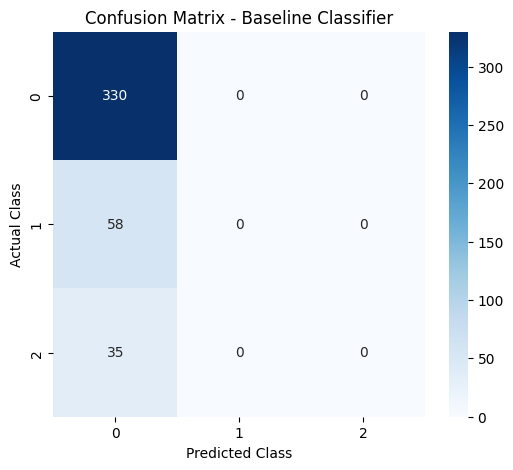

In [ ]:
baseline_result = evaluate_model(
    "Baseline Classifier",
    y_test,
    baseline_predictions
)

model_results.append(baseline_result)

**Observation:**  
The baseline classifier primarily reflects the majority-class distribution and does not provide meaningful classification performance for the minority classes.

Although its overall accuracy may appear relatively high, the class-specific metrics demonstrate why accuracy alone is insufficient for evaluating this imbalanced multiclass problem.

The baseline therefore serves as a minimum benchmark that the trained machine learning models should substantially outperform.

### 8.4 Logistic Regression

Logistic Regression is trained as the first machine learning classification model.

Although its name contains the word "regression," Logistic Regression is a classification algorithm. It provides a useful linear baseline for determining how well the fetal health classes can be separated using linear decision boundaries.

The standardized feature set is used because Logistic Regression can be sensitive to differences in feature scale.

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

logistic_model.fit(
    x_train_scaled,
    y_train
)
logistic_predictions = logistic_model.predict(
    x_test_scaled
)

Logistic Regression
--------------------------------------------------
Accuracy       : 0.8889
Macro Precision: 0.8214
Macro Recall   : 0.7613
Macro F1-score : 0.7885

Classification Report:

              precision    recall  f1-score   support

         1.0       0.92      0.96      0.94       330
         2.0       0.64      0.55      0.59        58
         3.0       0.90      0.77      0.83        35

    accuracy                           0.89       423
   macro avg       0.82      0.76      0.79       423
weighted avg       0.88      0.89      0.88       423



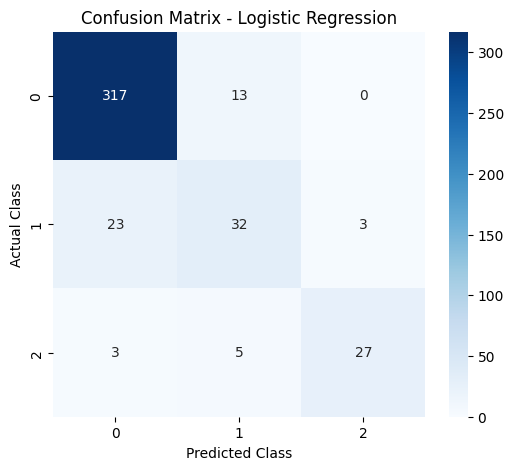

In [ ]:
logistic_result = evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_predictions
)

model_results.append(logistic_result)

### 8.5 Understanding the Confusion Matrix

The confusion matrix compares actual fetal health classes with the classes predicted by the model.

Values along the main diagonal represent correctly classified observations, while values outside the diagonal represent misclassifications.

Examining the confusion matrix is particularly useful in this project because it reveals whether the model performs well across all three fetal health classes rather than primarily predicting the majority class.

### 8.6 Initial Model Comparison

The baseline classifier and Logistic Regression model are compared using multiple evaluation metrics.

In [ ]:
results_df = pd.DataFrame(model_results)

results_df.set_index("Model").round(4)

,Accuracy,Macro Precision,Macro Recall,Macro F1
Model,,,,
Baseline Classifier,0.7801,0.2600,0.3333,0.2922
Logistic Regression,0.8889,0.8214,0.7613,0.7885


The current model results are visualized using Macro F1-score, which gives equal importance to each target class and is therefore particularly useful for this imbalanced classification problem.

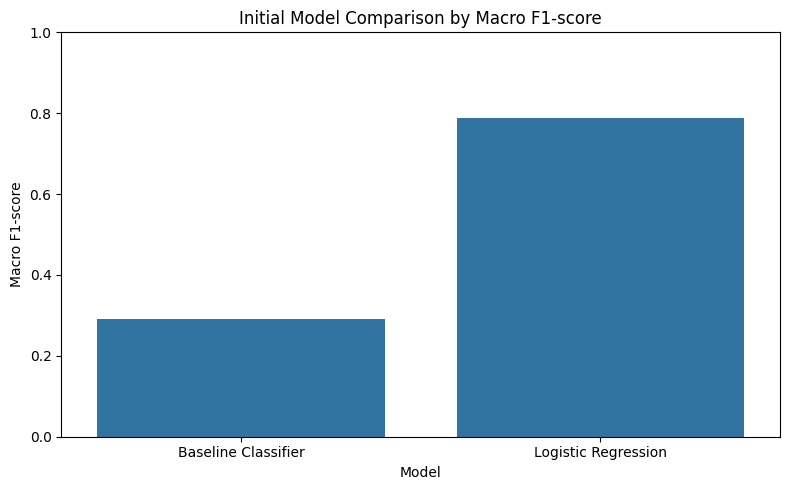

In [ ]:
comparison_df = pd.DataFrame(model_results)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Macro F1"
)

plt.title("Initial Model Comparison by Macro F1-score")
plt.ylabel("Macro F1-score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

### 8.7 K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a distance-based classification algorithm that predicts the class of an observation based on the classes of nearby training observations.

Because KNN relies on distance calculations, the standardized feature set is used to prevent features with larger numerical scales from dominating the distance calculation.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(
    x_train_scaled,
    y_train
)

knn_predictions = knn_model.predict(
    x_test_scaled
)

K-Nearest Neighbors
--------------------------------------------------
Accuracy       : 0.8889
Macro Precision: 0.8447
Macro Recall   : 0.7225
Macro F1-score : 0.7720

Classification Report:

              precision    recall  f1-score   support

         1.0       0.91      0.98      0.94       330
         2.0       0.70      0.53      0.61        58
         3.0       0.92      0.66      0.77        35

    accuracy                           0.89       423
   macro avg       0.84      0.72      0.77       423
weighted avg       0.88      0.89      0.88       423



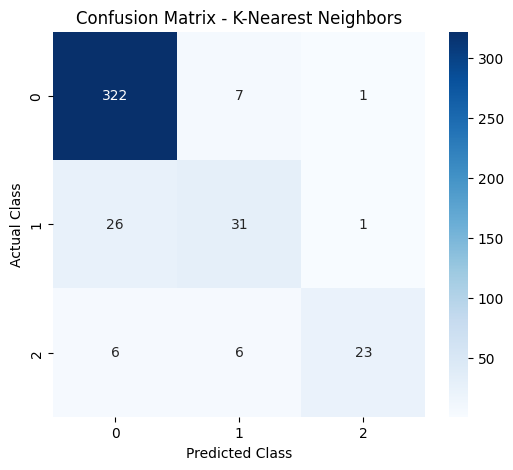

In [ ]:
knn_result = evaluate_model(
    "K-Nearest Neighbors",
    y_test,
    knn_predictions
)

model_results.append(knn_result)

### 8.8 Decision Tree Classifier

A Decision Tree classifies observations by learning a sequence of decision rules based on the predictor variables.

Unlike distance-based algorithms, Decision Trees do not require feature standardization because their decisions are based on feature thresholds.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    x_train,
    y_train
)

decision_tree_predictions = decision_tree_model.predict(
    x_test
)

Decision Tree
--------------------------------------------------
Accuracy       : 0.9338
Macro Precision: 0.8982
Macro Recall   : 0.8713
Macro F1-score : 0.8843

Classification Report:

              precision    recall  f1-score   support

         1.0       0.96      0.97      0.96       330
         2.0       0.80      0.76      0.78        58
         3.0       0.94      0.89      0.91        35

    accuracy                           0.93       423
   macro avg       0.90      0.87      0.88       423
weighted avg       0.93      0.93      0.93       423



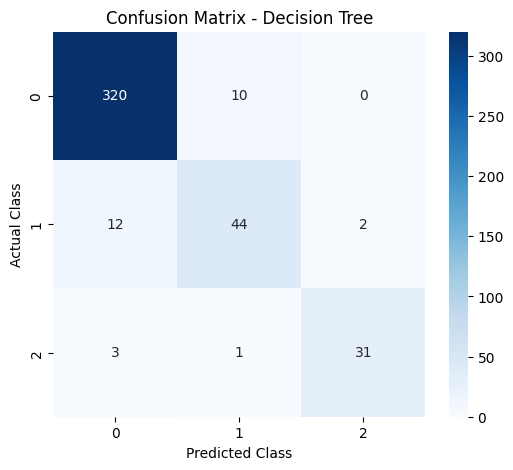

In [ ]:
decision_tree_result = evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_predictions
)

model_results.append(decision_tree_result)

### 8.9 Checking Decision Tree Generalization

Decision Trees can become overly complex and fit the training data too closely. Training and testing accuracy are therefore compared to identify potential overfitting.

In [ ]:
dt_train_accuracy = decision_tree_model.score(
    x_train,
    y_train
)

dt_test_accuracy = decision_tree_model.score(
    x_test,
    y_test
)

print(
    "Decision Tree Training Accuracy:",
    round(dt_train_accuracy, 4)
)

print(
    "Decision Tree Testing Accuracy:",
    round(dt_test_accuracy, 4)
)

print(
    "Train-Test Difference:",
    round(dt_train_accuracy - dt_test_accuracy, 4)
)

Decision Tree Training Accuracy: 0.9988
Decision Tree Testing Accuracy: 0.9338
Train-Test Difference: 0.065


### 8.10 Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines predictions from multiple Decision Trees.

By training multiple trees using different samples and subsets of features, Random Forest can reduce the instability and overfitting associated with a single Decision Tree while capturing nonlinear relationships in the data.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    x_train,
    y_train
)

random_forest_predictions = random_forest_model.predict(
    x_test
)

Random Forest
--------------------------------------------------
Accuracy       : 0.9527
Macro Precision: 0.9522
Macro Recall   : 0.8785
Macro F1-score : 0.9105

Classification Report:

              precision    recall  f1-score   support

         1.0       0.95      1.00      0.97       330
         2.0       0.93      0.72      0.82        58
         3.0       0.97      0.91      0.94        35

    accuracy                           0.95       423
   macro avg       0.95      0.88      0.91       423
weighted avg       0.95      0.95      0.95       423



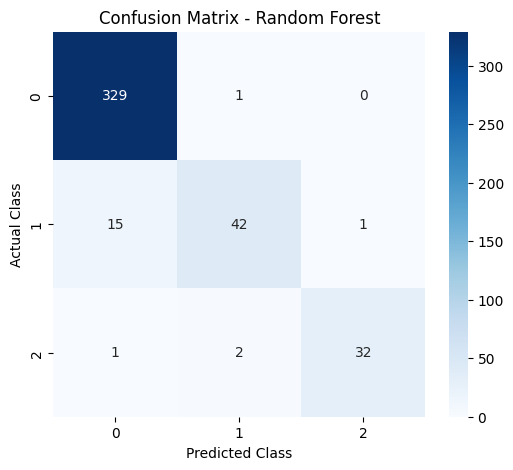

In [ ]:
random_forest_result = evaluate_model(
    "Random Forest",
    y_test,
    random_forest_predictions
)

model_results.append(random_forest_result)

### 8.11 Comparison of Classification Models

The baseline classifier and trained machine learning models are compared using accuracy, Macro Precision, Macro Recall, and Macro F1-score.

Macro-averaged metrics are particularly important because they assign equal importance to each fetal health class despite the class imbalance.

In [ ]:
results_df = pd.DataFrame(model_results)

results_df = results_df.sort_values(
    by="Macro F1",
    ascending=False
).reset_index(drop=True)

results_df.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.9527,0.9522,0.8785,0.9105
1,Decision Tree,0.9338,0.8982,0.8713,0.8843
2,Logistic Regression,0.8889,0.8214,0.7613,0.7885
3,K-Nearest Neighbors,0.8889,0.8447,0.7225,0.7720
4,Baseline Classifier,0.7801,0.2600,0.3333,0.2922


The models are visualized using Macro F1-score to compare their balanced performance across all target classes.

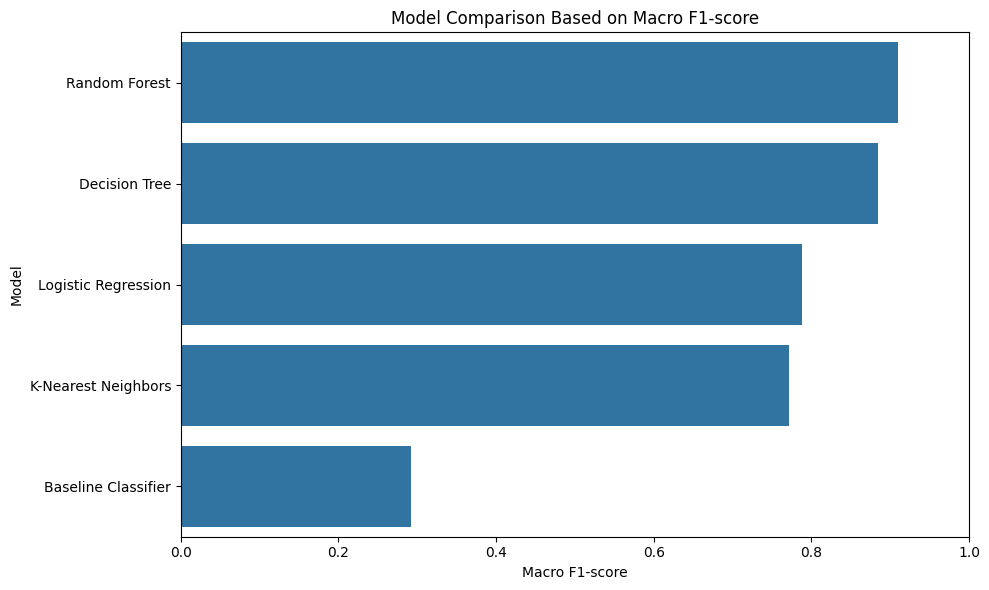

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Macro F1",
    y="Model"
)

plt.title("Model Comparison Based on Macro F1-score")
plt.xlabel("Macro F1-score")
plt.ylabel("Model")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()

Accuracy, Macro Precision, Macro Recall, and Macro F1-score are compared together to provide a broader view of model performance.

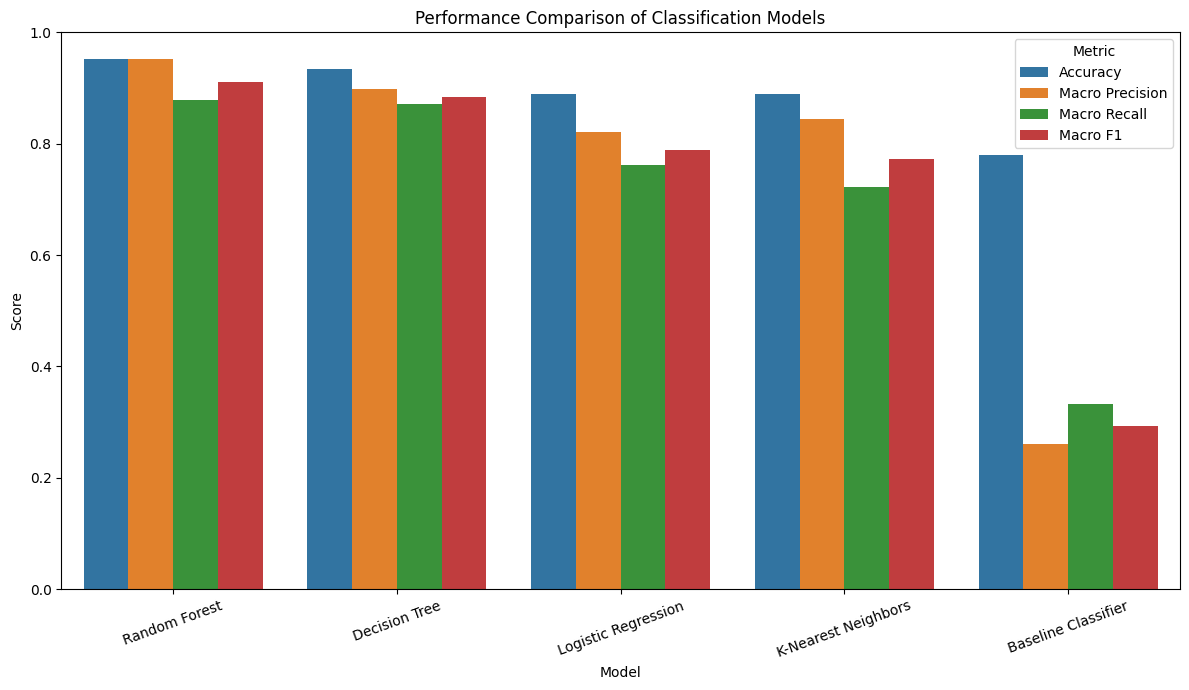

In [ ]:
comparison_plot = results_df.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=comparison_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Performance Comparison of Classification Models")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### 8.12 Identifying the Best Performing Model

The model with the highest Macro F1-score is identified as the strongest current candidate because Macro F1 gives equal importance to performance across all three target classes.

In [ ]:
best_model_row = results_df.loc[
    results_df["Macro F1"].idxmax()
]

print("Best current model:", best_model_row["Model"])
print(
    "Macro F1-score:",
    round(best_model_row["Macro F1"], 4)
)
print(
    "Accuracy:",
    round(best_model_row["Accuracy"], 4)
)

Best current model: Random Forest
Macro F1-score: 0.9105
Accuracy: 0.9527


### 8.13 Random Forest Feature Importance

Feature importance from the Random Forest model is examined to identify which predictor variables contributed most strongly to the model's classification decisions.

These importance values describe the model's predictive use of features and should not be interpreted as evidence of medical causation.

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
8,mean_value_of_short_term_variability,0.135235
7,abnormal_short_term_variability,0.131597
9,percentage_of_time_with_abnormal_long_term_var...,0.105360
17,histogram_mean,0.089890
6,prolongued_decelerations,0.056236
1,accelerations,0.054166
16,histogram_mode,0.053559
18,histogram_median,0.048711
10,mean_value_of_long_term_variability,0.047068
0,baseline value,0.039202


The ten most important Random Forest features are visualized to make their relative predictive contributions easier to interpret.

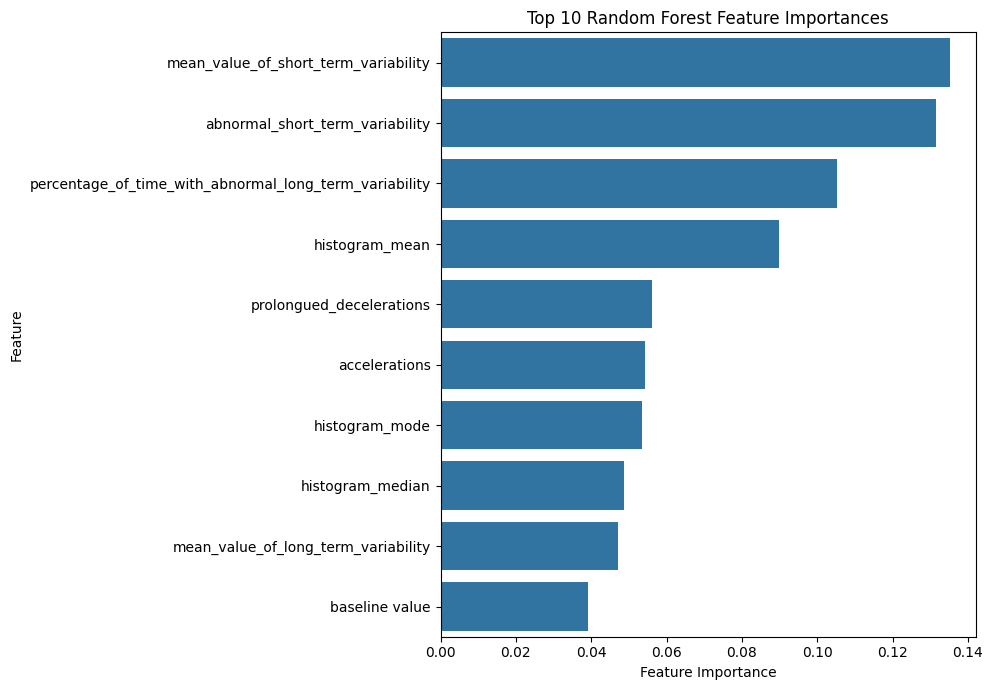

In [ ]:
top_10_importance = feature_importance.head(10)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_10_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 9. Model Validation and Improvement

The initial model comparison identified Random Forest as the strongest candidate based on Macro F1-score and overall classification performance.

To improve the reliability of model selection, further validation and hyperparameter optimization are performed using only the training data.

Cross-validation is used during this stage so that the test set can remain reserved for final model evaluation.

### 9.1 Stratified Cross-Validation

Stratified K-Fold cross-validation is used to evaluate the Random Forest model across multiple training-validation splits while approximately preserving the target-class proportions in each fold.

Macro F1-score is used as the primary scoring metric because all three fetal health classes should contribute equally to model evaluation.

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_cv_scores = cross_val_score(
    random_forest_model,
    x_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1
)

print("Cross-validation Macro F1-scores:")
print(rf_cv_scores)

print("\nMean CV Macro F1:",
      round(rf_cv_scores.mean(), 4))

print("Standard Deviation:",
      round(rf_cv_scores.std(), 4))

Cross-validation Macro F1-scores:
[0.86857949 0.8858186  0.85300495 0.90919374 0.88993389]

Mean CV Macro F1: 0.8813
Standard Deviation: 0.0192


### 9.2 Random Forest Hyperparameter Tuning

RandomizedSearchCV is used to explore different Random Forest configurations.

The search is performed only on the training data using stratified cross-validation and Macro F1-score as the optimization metric. This allows model parameters to be selected without using information from the held-out test set.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_distributions,
    n_iter=30,
    scoring="f1_macro",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(
    x_train,
    y_train
)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                   estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
                   n_iter=30, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 10, 20, 30],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 500]},
                   random_state=42, scoring='f1_macro', verbose=1)

### 9.3 Best Random Forest Configuration

The hyperparameter combination producing the highest cross-validated Macro F1-score is identified.

In [ ]:
print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest Cross-Validation Macro F1:")
print(round(rf_search.best_score_, 4))

Best Parameters:
{'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}

Best Cross-Validation Macro F1:
0.8881


The best-performing Random Forest configuration from cross-validation is selected as the final candidate model.

In [ ]:
best_rf_model = rf_search.best_estimator_

best_rf_model

RandomForestClassifier(class_weight='balanced', max_depth=20,
                       min_samples_leaf=2, n_estimators=500, n_jobs=-1,
                       random_state=42)

## 10. Final Model Evaluation

After model selection and hyperparameter optimization using only the training data, the optimized Random Forest model is evaluated on the held-out test set.

This test set was not used during hyperparameter selection, providing a final estimate of model performance on unseen observations.

Optimized Random Forest
--------------------------------------------------
Accuracy       : 0.9480
Macro Precision: 0.9271
Macro Recall   : 0.8944
Macro F1-score : 0.9092

Classification Report:

              precision    recall  f1-score   support

         1.0       0.96      0.98      0.97       330
         2.0       0.88      0.76      0.81        58
         3.0       0.94      0.94      0.94        35

    accuracy                           0.95       423
   macro avg       0.93      0.89      0.91       423
weighted avg       0.95      0.95      0.95       423



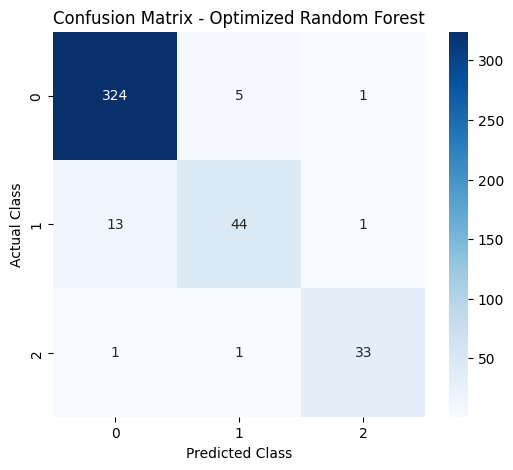

In [ ]:
final_predictions = best_rf_model.predict(
    x_test
)

final_result = evaluate_model(
    "Optimized Random Forest",
    y_test,
    final_predictions
)

### 10.1 Original and Optimized Random Forest Comparison

The original Random Forest model is compared with the cross-validation-optimized model to determine whether hyperparameter tuning improved balanced classification performance.

In [ ]:
rf_comparison = pd.DataFrame([
    random_forest_result,
    final_result
])

rf_comparison.round(4)

,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Random Forest,0.9527,0.9522,0.8785,0.9105
1,Optimized Random Forest,0.9480,0.9271,0.8944,0.9092


### 10.2 Final Confusion Matrix Interpretation

The final confusion matrix is examined to determine how accurately the optimized model distinguishes among the three fetal health classes.

Correct predictions appear along the main diagonal, while off-diagonal values represent misclassifications.

Particular attention is given to the minority classes because overall accuracy can otherwise conceal weaker performance on less frequently represented categories.

### 10.3 Final Model Feature Importance

Feature importance values from the optimized Random Forest model are examined to identify the predictors most influential in its classification decisions.

These values describe predictive importance within the fitted model and should not be interpreted as evidence of medical causation.

In [ ]:
final_feature_importance = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": best_rf_model.feature_importances_
})

final_feature_importance = (
    final_feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

final_feature_importance.head(10)

,Feature,Importance
0,abnormal_short_term_variability,0.135134
1,percentage_of_time_with_abnormal_long_term_var...,0.123337
2,histogram_mean,0.102264
3,histogram_median,0.084076
4,accelerations,0.078813
5,mean_value_of_short_term_variability,0.069914
6,mean_value_of_long_term_variability,0.059876
7,prolongued_decelerations,0.053226
8,histogram_mode,0.052561
9,baseline value,0.044449


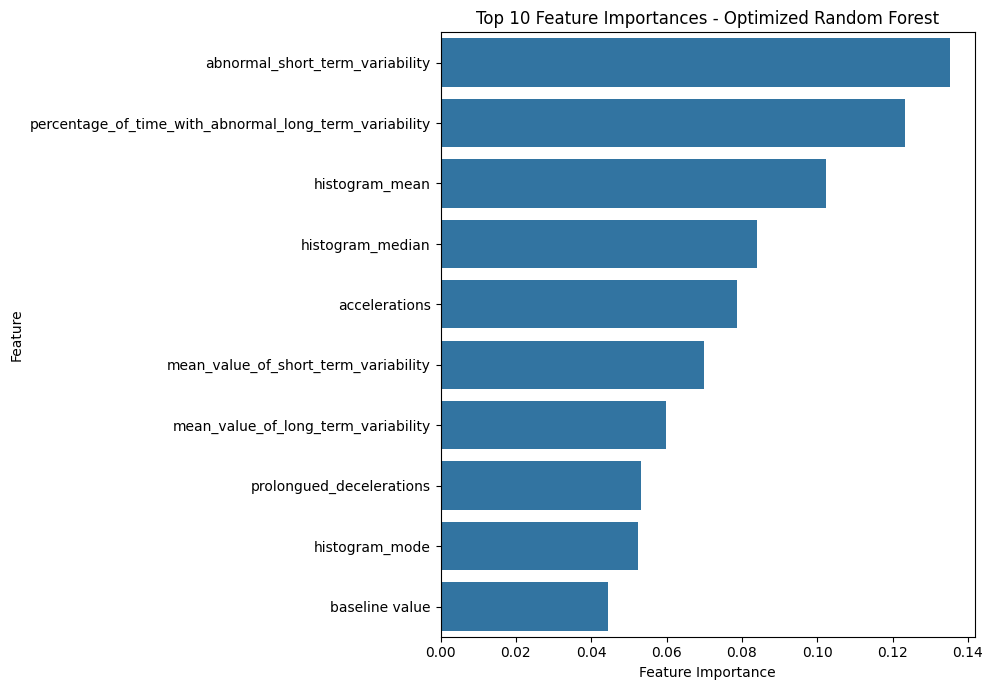

In [ ]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=final_feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importances - Optimized Random Forest"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 11. Saving the Final Model

The optimized machine learning model is saved so that it can be loaded later without retraining.

In [ ]:
import joblib

joblib.dump(
    best_rf_model,
    "fetal_health_random_forest_model.pkl"
)

print("Final model saved successfully.")

Final model saved successfully.


## 12. Results and Discussion

The initial Random Forest classifier achieved the highest performance among the baseline models, with an accuracy of 95.27% and a Macro F1-score of 91.05%.

Hyperparameter optimization was subsequently performed using stratified cross-validation and Macro F1-score. The best configuration used 500 trees, a maximum depth of 20, a minimum of 2 samples per leaf, square-root feature selection, and balanced class weights.

The optimized Random Forest achieved a cross-validation Macro F1-score of 88.81%. On the held-out test set, it achieved 94.80% accuracy and a Macro F1-score of 90.92%.

The optimized model performed particularly strongly for Classes 1.0 and 3.0. Class 1.0 achieved an F1-score of 0.97, while Class 3.0 achieved an F1-score of 0.94. Class 2.0 was comparatively more difficult to identify, achieving a recall of 0.76 and an F1-score of 0.81.

Overall, the results demonstrate that the Random Forest approach captured useful nonlinear patterns in the available fetal-health measurements while maintaining strong performance across the three target classes.

### 12.1 Effect of Hyperparameter Optimization

Hyperparameter optimization did not produce a higher held-out test score than the original Random Forest configuration.

The original Random Forest achieved 95.27% accuracy and a Macro F1-score of 91.05%, while the optimized model achieved 94.80% accuracy and a Macro F1-score of 90.92%.

This small reduction does not necessarily indicate that hyperparameter tuning failed. The optimized configuration was selected using performance across multiple stratified cross-validation folds rather than performance on the held-out test set. This provides a more systematic model-selection procedure and reduces reliance on a single train-test split.

The tuning process also selected balanced class weights, indicating that giving additional importance to minority-class observations was beneficial according to the cross-validation objective.

Because the difference between the original and optimized test Macro F1-scores is very small, both models demonstrate similarly strong predictive performance on the held-out data.

### 12.2 Class-Level Performance

The optimized model showed different levels of performance across the three target classes:

- **Class 1.0:** Precision = 0.96, Recall = 0.98, F1-score = 0.97
- **Class 2.0:** Precision = 0.88, Recall = 0.76, F1-score = 0.81
- **Class 3.0:** Precision = 0.94, Recall = 0.94, F1-score = 0.94

Class 1.0 was classified with very high reliability and represented the majority of test observations.

Class 3.0 also achieved strong precision and recall despite having only 35 observations in the test set.

Class 2.0 was the most challenging class for the model. Its recall of 0.76 indicates that some actual Class 2.0 observations were classified as another category.

These class-specific results reinforce the importance of examining precision, recall, F1-score, and the confusion matrix rather than relying only on overall accuracy.

### 12.3 Important Predictive Features

The optimized Random Forest identified the following variables among its most influential predictors:

1. `abnormal_short_term_variability`
2. `percentage_of_time_with_abnormal_long_term_variability`
3. `histogram_mean`
4. `histogram_median`
5. `accelerations`
6. `mean_value_of_short_term_variability`
7. `mean_value_of_long_term_variability`
8. `prolongued_decelerations`
9. `histogram_mode`
10. `baseline value`

Among these variables, `abnormal_short_term_variability` had the highest Random Forest feature importance, followed by `percentage_of_time_with_abnormal_long_term_variability` and `histogram_mean`.

These results indicate that the fitted model relied strongly on variability-related measurements, histogram-derived measurements, accelerations, and deceleration-related information when making classifications.

Feature importance represents the predictive contribution of variables within this fitted Random Forest model. It should not be interpreted as evidence that a feature independently causes a particular fetal health outcome.

## 13. Key Findings

The main findings of the project are:

- The cleaned dataset contained 2,113 observations, 21 predictor variables, and one multiclass target variable.
- The target variable was imbalanced, with Class 1.0 representing approximately 77.90% of observations.
- The baseline classifier achieved relatively high accuracy because of the majority class, but its Macro F1-score was only 0.2922, demonstrating why accuracy alone was inappropriate for model selection.
- Random Forest produced the strongest initial model performance, achieving 95.27% accuracy and a Macro F1-score of 0.9105.
- Decision Tree was the second strongest model, with 93.38% accuracy and a Macro F1-score of 0.8843.
- Logistic Regression and KNN produced similar overall accuracy but weaker Macro F1-scores than the tree-based models.
- Stratified cross-validation and hyperparameter optimization selected a balanced Random Forest configuration with a cross-validation Macro F1-score of 0.8881.
- The optimized Random Forest achieved 94.80% accuracy and a Macro F1-score of 0.9092 on the held-out test set.
- The optimized model performed particularly well for Classes 1.0 and 3.0, while Class 2.0 remained comparatively more difficult to identify.
- Variability-related and histogram-derived measurements were among the most influential predictors used by the optimized Random Forest.

## 14. Limitations

Although the machine learning models achieved strong predictive performance, several limitations should be considered:

1. The target classes are imbalanced, with substantially fewer observations in Classes 2.0 and 3.0 than in Class 1.0.
2. The dataset contains a limited number of observations, particularly for minority classes, which can affect the reliability of performance estimates.
3. The analysis is based on the variables available in this dataset and does not incorporate additional clinical information that may be relevant in real-world healthcare settings.
4. Random Forest feature importance indicates predictive contribution within the model but does not establish causal relationships.
5. Model performance was evaluated on a held-out portion of the same dataset source. External validation using independent data would be necessary before considering broader real-world use.
6. The project demonstrates a machine learning classification workflow and should not be interpreted as a substitute for professional medical assessment or clinical decision-making.

## 15. Recommendations and Future Work

Future work could extend this project in several ways:

- Evaluate the model using a larger and independently collected dataset.
- Investigate additional strategies for improving the identification of Class 2.0 observations.
- Compare additional ensemble algorithms and boosting-based classifiers.
- Perform more extensive hyperparameter optimization using nested or repeated cross-validation.
- Explore model-explanation techniques to better understand individual predictions.
- Evaluate calibration and other clinically relevant performance measures if the model were studied further for decision-support research.
- Assess model performance across independent populations or data sources to determine whether the learned patterns generalize.

## 16. Conclusion

This project developed an end-to-end machine learning workflow for multiclass fetal health classification using 21 predictor variables.

The analysis included data-quality assessment, duplicate removal, exploratory data analysis, stratified train-test splitting, feature scaling where appropriate, baseline evaluation, comparison of multiple classification algorithms, cross-validation, hyperparameter optimization, and feature-importance analysis.

Among the initially evaluated models, Random Forest achieved the strongest performance with an accuracy of 95.27% and a Macro F1-score of 0.9105. After systematic hyperparameter optimization using stratified cross-validation, the optimized Random Forest achieved 94.80% accuracy and a Macro F1-score of 0.9092 on the held-out test set.

The final model demonstrated strong classification performance for Classes 1.0 and 3.0, while Class 2.0 remained the most challenging category. Feature-importance analysis showed that variability-related and histogram-derived measurements were among the model's most influential predictors.

Overall, the project demonstrates how machine learning can identify useful predictive patterns within the provided fetal-health dataset. However, the results represent performance within this dataset and should not be interpreted as clinical validation or as a replacement for professional medical assessment.

---

## Project Summary

**Project:** Fetal Health Classification Using Machine Learning  
**Domain:** Healthcare  
**Problem Type:** Multiclass Classification  
**Cleaned Observations:** 2,113  
**Predictor Variables:** 21  
**Target Variable:** `fetal_health`  
**Models Evaluated:** Baseline Classifier, Logistic Regression, K-Nearest Neighbors, Decision Tree, Random Forest  
**Primary Selection Metric:** Macro F1-score  
**Best Initial Model:** Random Forest  
**Initial Random Forest Accuracy:** 95.27%  
**Initial Random Forest Macro F1:** 0.9105  
**Optimized Random Forest Accuracy:** 94.80%  
**Optimized Random Forest Macro F1:** 0.9092  
**Cross-Validation Macro F1:** 0.8881  
**Main Limitation:** Class imbalance and limited minority-class observations  

The completed workflow demonstrates data preparation, exploratory analysis, model development, evaluation, validation, optimization, interpretation, and responsible reporting of machine learning results.